# Polynomial Features: Beyond Straight Lines

**Goals for this notebook**

- See a dataset where logistic regression's straight-line boundary genuinely fails, and fix it with
  **polynomial features** -- still a *linear* model, just on transformed inputs.
- Pick up two small but important tools before we trust our comparisons: checking a result across
  several train/test splits (not just one), and evaluating with more than plain accuracy.
- Try polynomial features on **three real datasets** -- two where they genuinely help, and one where
  they don't -- and be honest about which is which and why.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 5)


## 1. A dataset a straight line can't separate

Every decision boundary we've drawn so far has been a straight line, because logistic regression's
boundary is exactly where $w^T x + b = 0$ -- linear in $x$. What if the true boundary is a **circle**?


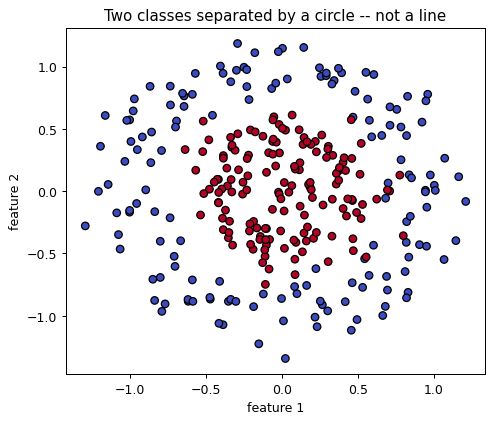

In [2]:
Xc, yc = make_circles(n_samples=300, noise=0.15, factor=0.4, random_state=42)

plt.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolor="k")
plt.title("Two classes separated by a circle -- not a line")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.show()


In [3]:
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.3, random_state=42, stratify=yc)

clf_lin = LogisticRegression().fit(Xtr, ytr)
print("plain logistic regression test accuracy:", clf_lin.score(Xte, yte))


plain logistic regression test accuracy: 0.45555555555555555


Barely better than a coin flip -- because no straight line can meaningfully separate a ring
from the disk inside it. Let's see the (useless) boundary it found.


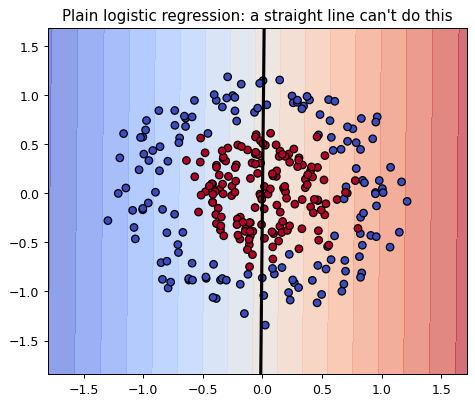

In [4]:
def plot_boundary(clf_or_fn, X, y, ax=None, title="", is_pipeline=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300), np.linspace(x2_min, x2_max, 300))
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    probs = clf_or_fn(grid).reshape(xx1.shape)
    cs = ax.contourf(xx1, xx2, probs, levels=20, cmap="coolwarm", alpha=0.65)
    ax.contour(xx1, xx2, probs, levels=[0.5], colors="black", linewidths=2.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
    ax.set_title(title)
    return cs

fig, ax = plt.subplots(figsize=(6, 5))
plot_boundary(lambda g: clf_lin.predict_proba(g)[:, 1], Xc, yc, ax, "Plain logistic regression: a straight line can't do this")
plt.show()


**Try it yourself, before reading on:** we're only allowed a *linear* model -- but what if we
engineer new features first? Is there a transformation of $(x_1, x_2)$ under which "inside vs outside
a circle" becomes a *linear* condition? (Hint: the equation of a circle is $x_1^2 + x_2^2 = r^2$ --
what does that look like if you treat $x_1^2$ and $x_2^2$ as new features?)


## 2. Polynomial features: still a linear model, richer inputs

The trick: instead of feeding $(x_1, x_2)$ into logistic regression, feed in $(x_1, x_2, x_1^2, x_1
x_2, x_2^2, \dots)$ -- every monomial up to some degree. Logistic regression still only ever draws a
**linear** boundary, but now it's linear *in the new, expanded feature space* -- which corresponds to
a **curved** boundary back in the original $(x_1, x_2)$ space. `sklearn`'s `PolynomialFeatures` builds
these new columns for us.


In [5]:
poly = PolynomialFeatures(degree=2, include_bias=False)
Xtr_p = poly.fit_transform(Xtr)
Xte_p = poly.transform(Xte)

print("original feature count:", Xtr.shape[1])
print("degree-2 polynomial feature count:", Xtr_p.shape[1])
print("new feature names:", poly.get_feature_names_out(["x1", "x2"]))

clf_poly = LogisticRegression(max_iter=5000).fit(Xtr_p, ytr)
print("degree-2 test accuracy:", clf_poly.score(Xte_p, yte))


original feature count: 2
degree-2 polynomial feature count: 5
new feature names: ['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']
degree-2 test accuracy: 1.0


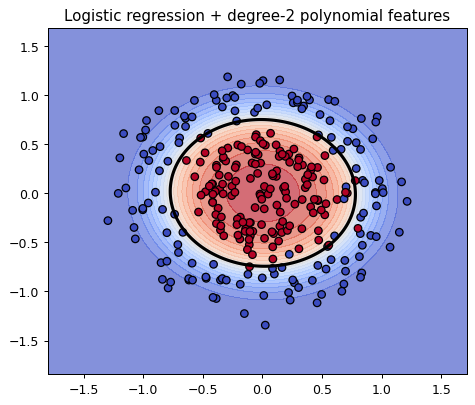

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
predict_fn = lambda g: clf_poly.predict_proba(poly.transform(g))[:, 1]
plot_boundary(predict_fn, Xc, yc, ax, "Logistic regression + degree-2 polynomial features")
plt.show()


A genuinely curved boundary, from a model that is -- underneath -- still just a linear
classifier on an expanded set of features.


## 3. How much degree do we need?

More degree = more flexible boundary, but also more parameters to fit (risk of overfitting) and more
compute. Let's sweep the degree and look at train vs. test accuracy.


degree=1   n_features=2    train_acc=0.500  test_acc=0.456
degree=2   n_features=5    train_acc=0.957  test_acc=1.000
degree=3   n_features=9    train_acc=0.952  test_acc=1.000
degree=4   n_features=14   train_acc=0.938  test_acc=1.000
degree=6   n_features=27   train_acc=0.929  test_acc=1.000
degree=8   n_features=44   train_acc=0.929  test_acc=1.000


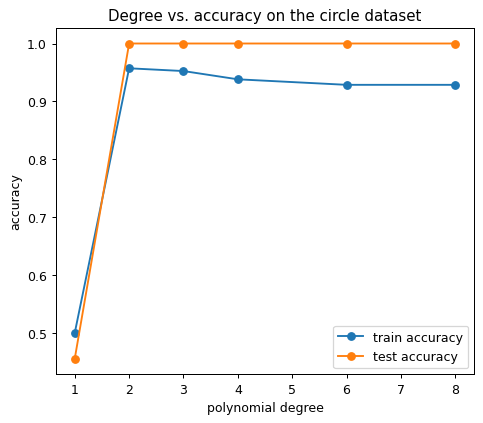

In [7]:
degrees = [1, 2, 3, 4, 6, 8]
train_accs, test_accs, n_feats = [], [], []

for d in degrees:
    p = PolynomialFeatures(degree=d, include_bias=False)
    Xtr_d = p.fit_transform(Xtr)
    Xte_d = p.transform(Xte)
    clf_d = LogisticRegression(max_iter=5000).fit(Xtr_d, ytr)
    train_accs.append(clf_d.score(Xtr_d, ytr))
    test_accs.append(clf_d.score(Xte_d, yte))
    n_feats.append(Xtr_d.shape[1])

for d, tr, te, nf in zip(degrees, train_accs, test_accs, n_feats):
    print(f"degree={d:<3} n_features={nf:<4} train_acc={tr:.3f}  test_acc={te:.3f}")

plt.plot(degrees, train_accs, "o-", label="train accuracy")
plt.plot(degrees, test_accs, "o-", label="test accuracy")
plt.xlabel("polynomial degree"); plt.ylabel("accuracy")
plt.title("Degree vs. accuracy on the circle dataset")
plt.legend()
plt.show()


Degree 1 (no transformation) fails; degree 2 already solves it almost perfectly, because the
*true* boundary really is a degree-2 curve (a circle). Going well beyond the true degree doesn't buy
us anything here and, on noisier or smaller datasets, would start fitting noise instead of signal --
the classic **overfitting** trade-off. (Remember from notebook 03b: `sklearn`'s `LogisticRegression` applies L2
regularization by default -- via the `C` parameter -- which is the standard way to keep a high-degree
polynomial model from overfitting; smaller `C` means stronger regularization.)


## 4. Can we trust a *single* train/test split?

So far every improvement we've looked at (circles: 51% &rarr; 99%) has been huge and obvious -- one
split was plenty to see it. On real data the improvement from polynomial features is often much
smaller, sometimes just a couple of percentage points. Before we go compare models that closely,
let's check something: how much does accuracy change just from **which random split** we happen to
use, with everything else held fixed?


In [8]:
# Same model, same data, same everything -- except the random train/test split.
accs = []
for seed in range(10):
    Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(Xc, yc, test_size=0.3, random_state=seed, stratify=yc)
    clf = LogisticRegression().fit(Xtr_s, ytr_s)
    accs.append(clf.score(Xte_s, yte_s))

for seed, a in enumerate(accs):
    print(f"split {seed}: accuracy = {a:.3f}")
print(f"\nrange across 10 splits: {min(accs):.3f} to {max(accs):.3f}  (spread of {max(accs)-min(accs):.3f})")


split 0: accuracy = 0.422
split 1: accuracy = 0.400
split 2: accuracy = 0.456
split 3: accuracy = 0.456
split 4: accuracy = 0.456
split 5: accuracy = 0.489
split 6: accuracy = 0.489
split 7: accuracy = 0.500
split 8: accuracy = 0.500
split 9: accuracy = 0.456

range across 10 splits: 0.400 to 0.500  (spread of 0.100)


The exact same model swings by several percentage points depending purely on *which 90 test
points happened to land in the test set*. If two models differ by less than that swing, a single split
can't reliably tell them apart -- you could get a "winner" just from being lucky (or unlucky) with the
split.

**The fix we'll use for the rest of this notebook:** instead of one split, try **several** random
splits and look at the whole spread, not one number. (This idea has a proper name and a more efficient
version -- **cross-validation** -- which you'll likely see in a later course; the "try several splits"
version here is the same idea in its simplest form.)


**A new tool in the next cell: pipelines.** `make_pipeline(StandardScaler(), LogisticRegression())`
chains the steps into a single model object. When we call `.fit(X_train, y_train)` on it, it fits the
scaler on the training data, transforms it, and fits the logistic regression on the result. When we call
`.predict` or `.predict_proba` on new data, it transforms that data with the **training** means and
standard deviations first. So it does exactly what we did by hand in notebook 02 -- scale using the
training part only -- but automatically, and without any chance of forgetting a step. That matters here
because we'll refit on many different splits: the pipeline guarantees the scaler is re-fit on the
training part of **each** split. (`poly_model` adds one more step in the middle, `PolynomialFeatures`.)

In [9]:
def compare_across_splits(build_models, X, y, n_splits=8, test_size=0.3, seed0=0):
    """Fit each model in build_models (a dict name -> zero-arg constructor) on n_splits
    different random train/test splits, and collect accuracy / F1 / AUC for each."""
    rows = []
    for i in range(n_splits):
        seed = seed0 + i
        Xtr_i, Xte_i, ytr_i, yte_i = train_test_split(
            X, y, test_size=test_size, random_state=seed, stratify=y)
        for name, build in build_models.items():
            model = build()
            model.fit(Xtr_i, ytr_i)
            pred = model.predict(Xte_i)
            proba = model.predict_proba(Xte_i)[:, 1]
            rows.append({
                "split": i, "model": name,
                "accuracy": accuracy_score(yte_i, pred),
                "f1": f1_score(yte_i, pred),
                "auc": roc_auc_score(yte_i, proba),
            })
    return pd.DataFrame(rows)


def summarize(results):
    """Mean +/- std of each metric, per model."""
    return results.groupby("model")[["accuracy", "f1", "auc"]].agg(["mean", "std"]).round(4)


from sklearn.pipeline import make_pipeline

def linear_model(C=1.0):
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=C))

def poly_model(degree=2, C=1.0):
    return make_pipeline(StandardScaler(), PolynomialFeatures(degree=degree, include_bias=False),
                          LogisticRegression(max_iter=5000, C=C))


def plot_splits(results, metric="accuracy", title=""):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for name, g in results.groupby("model"):
        g = g.sort_values("split")
        ax.plot(g["split"], g[metric], "o-", label=name)
    ax.set_xlabel("split #"); ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    plt.show()


## 5. Quick recap: evaluating classifiers beyond accuracy

You already met these tools in notebook 01b (confusion matrix, precision/recall, ROC/AUC) -- here's a
30-second recap of the three we'll actually use below, since the rest of this notebook leans on them.


In [10]:
cancer = load_breast_cancer()
Xb, yb = cancer.data, 1 - cancer.target      # flip the labels, as in 02: 1 = malignant, 0 = benign
Xbtr, Xbte, ybtr, ybte = train_test_split(Xb, yb, test_size=0.3, random_state=42, stratify=yb)
sc = StandardScaler().fit(Xbtr)
clf_recap = LogisticRegression(max_iter=5000).fit(sc.transform(Xbtr), ybtr)
pred_recap = clf_recap.predict(sc.transform(Xbte))
proba_recap = clf_recap.predict_proba(sc.transform(Xbte))[:, 1]

cm = confusion_matrix(ybte, pred_recap)
print("confusion matrix (rows=true, cols=predicted):")
print(cm)
print(f"\naccuracy = (TP+TN)/total = {accuracy_score(ybte, pred_recap):.3f}")
print(f"F1 (balances precision & recall) = {f1_score(ybte, pred_recap):.3f}")
print(f"AUC (ranks probabilities, ignores threshold) = {roc_auc_score(ybte, proba_recap):.3f}")


confusion matrix (rows=true, cols=predicted):
[[106   1]
 [  4  60]]

accuracy = (TP+TN)/total = 0.971
F1 (balances precision & recall) = 0.960
AUC (ranks probabilities, ignores threshold) = 0.998


- **Confusion matrix**: counts of correct/incorrect predictions, broken down by which mistake
  (false positive vs. false negative) -- accuracy alone hides *which kind* of error a model makes.
- **F1**: the harmonic mean of precision and recall, in a single number -- handy for comparing models
  when you care about both kinds of error together (and especially when classes are imbalanced, where
  accuracy can look good while missing most of the minority class).
- **AUC**: how well the model's predicted *probabilities* rank positives above negatives, across every
  possible decision threshold at once -- unlike accuracy or F1, it doesn't depend on picking 0.5 as the
  cutoff. This is why we'll use AUC as our main "which model is better" number below.

We'll report all three (accuracy, F1, AUC) for every comparison from here on, averaged across the
8 splits from `compare_across_splits`.


## 6. Real dataset #1: Titanic -- does polynomial help?

839 passengers, `Pclass` (ticket class), `Sex`, `Age`, `SibSp`/`Parch` (family aboard), `Fare`, and
`Embarked` (port), predicting `Survived`. A well-known fact about this dataset: survival wasn't well
explained by any *one* of these features alone -- famously, "women and children first" applied far more
strongly in 1st/2nd class than in 3rd class. That's an **interaction** between `Age`, `Sex`, and
`Pclass` -- exactly the kind of structure polynomial features (which add products of features, not
just the features themselves) can capture that a plain linear model can't.


In [11]:
titanic = pd.read_csv("../data/titanic.csv")
titanic = titanic.dropna(subset=["Fare"])  # one incomplete row
print(titanic.shape)
titanic.head()


(839, 9)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [12]:
# A quick look at the "women and children first, unevenly by class" story before we model it:
titanic["is_child"] = titanic["Age"] < 16
child_survival = titanic.groupby(["Pclass", "is_child"])["Survived"].mean().unstack()
child_survival.columns = ["adults", "children"]
print("survival rate by class and (child vs adult):")
print(child_survival.round(2))


survival rate by class and (child vs adult):
        adults  children
Pclass                  
1         0.61      0.83
2         0.42      1.00
3         0.22      0.43


Children survived at a much higher rate than adults in every class -- but the *size* of that
gap is very different in 1st/3rd class. That "it depends on class" pattern is an interaction, not
something a linear-in-`Age`-and-`Pclass` model can represent on its own.


**A note on categorical features.** `Sex` has two values, so a single 0/1 column (`Sex_male`) is
enough. `Embarked` (the port where the passenger boarded) has **three** values: `C`, `Q` and `S`. We
can't just code them as 1, 2, 3 -- that would tell the model that `Q` is "between" `C` and `S`, and
that the difference between `C` and `S` is twice the difference between `C` and `Q`, which is
meaningless. Instead we use **one-hot encoding**: one 0/1 column per value (`Embarked_C`,
`Embarked_Q`, `Embarked_S`), with a 1 in the column of the passenger's port and 0 in the others.
`pd.get_dummies` does exactly this. (`dummy_na=True` adds one more column for passengers whose port is
unknown.)

In [13]:
y_titanic = titanic["Survived"].values
num_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
X_titanic = titanic[num_cols].copy()
X_titanic["Age"] = X_titanic["Age"].fillna(X_titanic["Age"].median())
X_titanic["Sex_male"] = (titanic["Sex"] == "male").astype(int)
X_titanic = pd.concat([X_titanic, pd.get_dummies(titanic["Embarked"], prefix="Embarked", dummy_na=True)], axis=1)
X_titanic = X_titanic.astype(float).values

print("feature count:", X_titanic.shape[1], " rows:", X_titanic.shape[0])


feature count: 10  rows: 839


                    accuracy              f1             auc        
                        mean     std    mean     std    mean     std
model                                                               
degree-2 polynomial   0.8065  0.0218  0.7256  0.0324  0.8568  0.0182
linear (baseline)     0.7902  0.0123  0.7245  0.0186  0.8461  0.0200


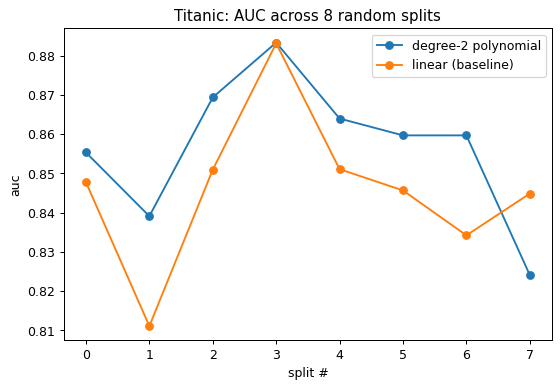

In [14]:
results_titanic = compare_across_splits(
    {"linear (baseline)": linear_model, "degree-2 polynomial": lambda: poly_model(C=0.3)},
    X_titanic, y_titanic, n_splits=8)

print(summarize(results_titanic))
plot_splits(results_titanic, "auc", "Titanic: AUC across 8 random splits")


The polynomial model comes out ahead on AUC in most (not all -- that's expected, and part of
why we're looking at several splits) of the 8 runs, and its *average* AUC is consistently a bit higher.
The improvement is modest -- a couple of AUC points -- but it's a real, repeatable effect coming from
letting the model represent `Age`&times;`Pclass` and `Age`&times;`Sex` style interactions, not a fluke
of one lucky split.


## 7. Real dataset #2: Ionosphere -- a much bigger effect

Radar signals bounced off the ionosphere, described by 33 numeric measurements per return; the task is
to classify each return as "good" (structure detected) or "bad" (noise). Unlike Titanic, there's no
single simple story here for *why* polynomial features should help -- but radar returns are governed by
wave interference, which is a fundamentally **non-linear** function of the raw signal measurements. If
polynomial features ever earn their keep, this is the kind of dataset where we'd expect it.


In [15]:
iono = pd.read_csv("../data/ionosphere.csv")
iono = iono.drop(columns=["a2"])  # this column is always 0 -- no information
y_iono = (iono["class"] == "g").astype(int).values
X_iono = iono.drop(columns=["class"]).astype(float).values

print("feature count:", X_iono.shape[1], " rows:", X_iono.shape[0])
print("class balance (good radar returns):", y_iono.mean().round(3))


feature count: 33  rows: 229
class balance (good radar returns): 0.502


                    accuracy              f1             auc        
                        mean     std    mean     std    mean     std
model                                                               
degree-2 polynomial   0.9185  0.0256  0.9254  0.0217  0.9743  0.0228
linear (baseline)     0.8424  0.0284  0.8545  0.0283  0.9126  0.0117


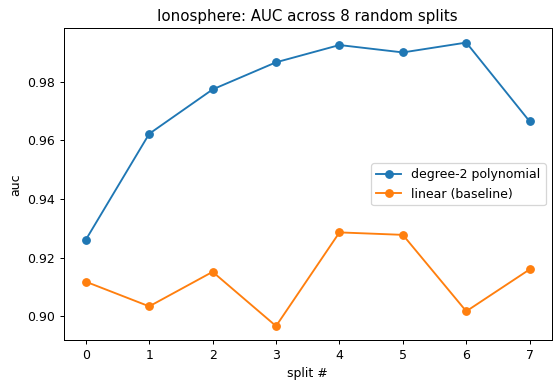

In [16]:
results_iono = compare_across_splits(
    {"linear (baseline)": linear_model, "degree-2 polynomial": lambda: poly_model(C=0.1)},
    X_iono, y_iono, n_splits=8)

print(summarize(results_iono))
plot_splits(results_iono, "auc", "Ionosphere: AUC across 8 random splits")


This time the polynomial model wins **every single split**, by a wide margin (roughly 0.90
AUC &rarr; 0.97+ AUC on average) -- a much more dramatic and unambiguous improvement than Titanic. The
degree-2 features expand 33 raw measurements into several hundred products and squares; with a fairly
small dataset (229 rows) that could easily overfit, which is why we used a fairly strong regularization
(`C=0.1`, see 03b) -- worth trying a few other `C` values yourself and seeing how the AUC changes.


## 8. Real dataset #3: breast cancer -- when it *doesn't* help

Back to the dataset from notebook 02 (with the labels flipped as there: 1 = malignant). This time,
let's see what happens if we're **not** careful.


### First attempt: throw degree-2 polynomial features at all 30 features, with little data

30 features become ~495 degree-2 polynomial features. To make the "too many parameters, too little
data" problem unambiguous, let's deliberately train on a *small* slice of the data (about 115 patients)
and test on the rest -- exactly the situation where 495 features should be dangerous.


                              accuracy              f1             auc        
                                  mean     std    mean     std    mean     std
model                                                                         
degree-2 poly (~495 features)   0.9301  0.0084  0.9036  0.0133  0.9749  0.0063
linear (30 features)            0.9652  0.0100  0.9521  0.0137  0.9926  0.0025


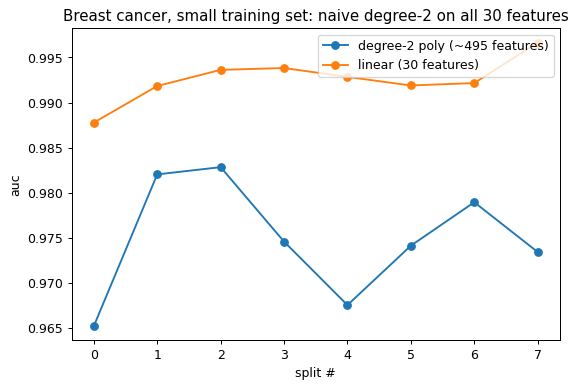

In [17]:
cancer = load_breast_cancer()
Xcan, ycan = cancer.data, 1 - cancer.target      # 1 = malignant, 0 = benign (as in 02)

results_cancer_naive = compare_across_splits(
    {"linear (30 features)": lambda: linear_model(C=1.0),
     "degree-2 poly (~495 features)": lambda: poly_model(C=1.0, degree=2)},
    Xcan, ycan, n_splits=8, test_size=0.8)

print(summarize(results_cancer_naive))
plot_splits(results_cancer_naive, "auc", "Breast cancer, small training set: naive degree-2 on all 30 features")


**This makes things worse, consistently -- the polynomial model loses on every single split.**
With only ~115 training examples and ~495 polynomial features, the model has more than enough freedom
to memorize quirks of the training set without that generalizing to new patients. This is overfitting in
a very literal, countable sense: **parameters outnumbering examples.**

Worth asking, though: **is that really about the *polynomial features*, or just about training on too
little data?** Let's check with the training set size we've been using everywhere else (70%, roughly
400 patients) instead.


In [18]:
results_cancer_naive_normal = compare_across_splits(
    {"linear (30 features)": lambda: linear_model(C=1.0),
     "degree-2 poly (~495 features)": lambda: poly_model(C=1.0, degree=2)},
    Xcan, ycan, n_splits=8, test_size=0.3)

print(summarize(results_cancer_naive_normal))


                              accuracy              f1             auc        
                                  mean     std    mean     std    mean     std
model                                                                         
degree-2 poly (~495 features)   0.9554  0.0112  0.9386  0.0159  0.9858  0.0059
linear (30 features)            0.9671  0.0112  0.9549  0.0158  0.9924  0.0040


With a normal-sized training set, the gap **shrinks a lot** -- from about 0.02 AUC to less than
0.01 -- but the polynomial model still loses on every split. That fits the "parameters vs. examples"
explanation: ~495 features was a serious problem against ~115 examples, and a much smaller (but still
real) one against ~400.

**So does polynomial ever pay off here at all**, the way it did for Titanic and Ionosphere?


### A fairer test: polynomial features on a *small*, informative feature set

Let's remove the "too many parameters" problem entirely by picking just the two most informative
features first, and comparing a linear model to a degree-2 polynomial model **on that same pair** --
few enough parameters that overfitting isn't a factor either way.


In [19]:
selector = SelectKBest(f_classif, k=2).fit(StandardScaler().fit_transform(Xcan), ycan)
top2_idx = selector.get_support(indices=True)
top2_names = cancer.feature_names[top2_idx]
print("selected features:", list(top2_names))

Xcan2 = Xcan[:, top2_idx]

results_cancer_fair = compare_across_splits(
    {"linear (2 features)": linear_model, "degree-2 poly (same 2 features)": poly_model},
    Xcan2, ycan, n_splits=8)

print(summarize(results_cancer_fair))


selected features: [np.str_('worst perimeter'), np.str_('worst concave points')]
                                accuracy          ...     auc        
                                    mean     std  ...    mean     std
model                                             ...                
degree-2 poly (same 2 features)   0.9291  0.0170  ...  0.9815  0.0060
linear (2 features)               0.9254  0.0248  ...  0.9806  0.0065

[2 rows x 6 columns]


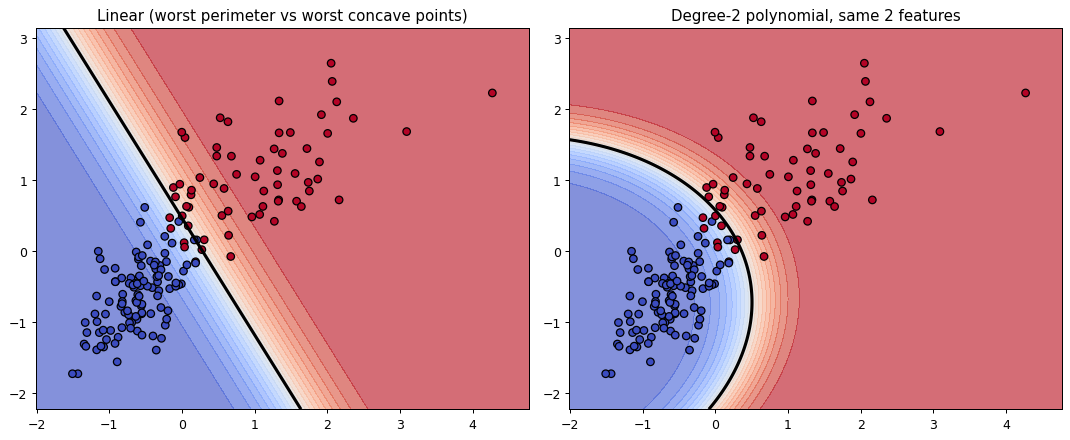

In [20]:
# Boundary plot on one representative split, just to see the shape of the fix
Xtr2, Xte2, ytr2, yte2 = train_test_split(Xcan2, ycan, test_size=0.3, random_state=42, stratify=ycan)
sc2 = StandardScaler().fit(Xtr2)
lin2 = LogisticRegression().fit(sc2.transform(Xtr2), ytr2)
poly2 = PolynomialFeatures(degree=2, include_bias=False)
Xtr2p = poly2.fit_transform(sc2.transform(Xtr2))
clf2p = LogisticRegression(max_iter=5000).fit(Xtr2p, ytr2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_boundary(lambda g: lin2.predict_proba(g)[:, 1], sc2.transform(Xte2), yte2, axes[0],
              f"Linear ({top2_names[0]} vs {top2_names[1]})")
plot_boundary(lambda g: clf2p.predict_proba(poly2.transform(g))[:, 1], sc2.transform(Xte2), yte2, axes[1],
              "Degree-2 polynomial, same 2 features")
plt.tight_layout()
plt.show()


Even here -- plenty of data, no overfitting risk, an honest comparison -- the two models are
essentially **tied**. Look closely at the two boundaries above: the polynomial one *does* curve, but
mostly out where there are few patients. In the region that matters -- where the two groups meet --
both boundaries run through almost the same place, so they classify almost every patient the same way.
Unlike Titanic (a real interaction between `Age`, `Sex`, and `Pclass`) or Ionosphere (wave-interference
patterns that are inherently non-linear), the relationship between these tumor measurements and
malignancy turns out to already be close to linear -- there's no curved structure here for polynomial
features to capture. **No non-linear signal in the data means no benefit from features designed to
capture non-linear signal**, no matter how carefully you avoid overfitting.


## Recap

- Polynomial features let a linear model (logistic regression) fit curved boundaries, by giving it
  $x_1^2, x_1 x_2, x_2^2, \dots$ as additional inputs.
- **A single train/test split isn't enough** to trust a comparison, especially when the effect is
  small -- we used several random splits throughout and looked at the spread, not just one number.
- We compared models with **accuracy, F1, and AUC**, not accuracy alone -- AUC in particular, since it
  doesn't depend on picking a decision threshold.
- **Titanic**: a modest but real, repeatable improvement -- polynomial features let the model capture
  `Age`&times;`Pclass`&times;`Sex`-style interactions that a linear model can't.
- **Ionosphere**: a large, unambiguous improvement (wins every split) -- radar signals have inherently
  non-linear structure, and with a strong-enough regularization the extra features paid off.
- **Breast cancer**: two different ways to *not* benefit. Throwing ~495 features at too little data
  overfits badly (parameters outnumbering examples); done fairly with plenty of data, it's just a wash
  -- because unlike Titanic and Ionosphere, this dataset's true decision boundary is already close to
  linear, so there's no curved structure for polynomial features to capture in the first place.
- Polynomial features pay off only when **both** conditions hold: there's genuine non-linear structure
  in the data, *and* you have enough data (or strong enough regularization) to support the extra
  parameters. Neither condition alone is enough.
